Cat recogniton using the transfer learning approach. using a pre-trained(MobileNetV2) model. Keras CIFAR-10 dataset used

In [1]:
#TensorFLow and Keras libraries used for deep learning, Numpy for numerical operations, Matprolib for visualisation

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

import numpy as np
import matplotlib.pyplot as plt

2024-08-31 10:21:10.490413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-31 10:21:10.499785: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-31 10:21:10.502614: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-31 10:21:10.510533: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-31 10:21:11.051632: W tensorflow/compiler/tf2

In [2]:
#confusion matrix libraries
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [3]:
#ROC libraries
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [4]:
#loading and preprocessing the dataset

(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()


In [5]:
#Filtering out cat pictures only (class 3 in CIFAR-10) and non-cat images
cat_train = train_images[train_labels.flatten() == 3]
non_cat_train = train_images[train_labels.flatten() != 3]
cat_test = test_images[test_labels.flatten() == 3]
non_cat_test = test_images[test_labels.flatten() != 3]

print(cat_train.shape)
print(non_cat_train.shape)
print(cat_test.shape)
print(non_cat_test.shape)

# Combine cat and non-cat images
train_images = np.vstack((cat_train, non_cat_train[:len(cat_train)]))
test_images = np.vstack((cat_test, non_cat_test[:len(cat_test)]))

# Create labels (1 for cat, 0 for non-cat)
train_labels = np.hstack((np.ones(len(cat_train)), np.zeros(len(cat_train))))
test_labels = np.hstack((np.ones(len(cat_test)), np.zeros(len(cat_test))))

# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Resize images to match MobileNetV2 input size //MobileNetV2 as the base model, which is pre-trained on ImageNet//
train_images = tf.image.resize(train_images, (224, 224))
test_images = tf.image.resize(test_images, (224, 224))

(5000, 32, 32, 3)
(45000, 32, 32, 3)
(1000, 32, 32, 3)
(9000, 32, 32, 3)


I0000 00:00:1725099673.265909 1564631 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725099673.287431 1564631 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725099673.287597 1564631 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725099673.289546 1564631 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

# **Data augmentation**

In [6]:
# set up image augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.10
    )
datagen.fit(train_images)

2024-08-31 10:21:13.788376: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 6021120000 exceeds 10% of free system memory.


In [7]:
print(test_labels)

[1. 1. 1. ... 0. 0. 0.]


In [8]:
#creating the model - Convolutional Neural Network based on transfer learning
#using MobileNetV2 as the pre-trained base model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

In [9]:
# Step 4: Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [10]:
# Step 5: Train the model
#history = model.fit(train_images, train_labels, epochs=20,
#                    validation_split=0.2, batch_size=32)

#history = model.fit(train_images, train_labels, epochs=20,
#                    validation_data=(test_images, test_labels), batch_size=32)
history = model.fit(datagen.flow(train_images, train_labels, batch_size=32),
                    validation_data=(test_images, test_labels), epochs=20)


Epoch 1/20


/home/jupyter-mwolter/.local/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1725099681.043455 1564778 service.cc:146] XLA service 0x7ff4cc00df90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1725099681.043483 1564778 service.cc:154]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2024-08-31 10:21:21.098824: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-08-31 10:21:21.458746: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2024-08-31 10:21

  3/313 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step - accuracy: 0.5469 - loss: 0.7275

I0000 00:00:1725099684.997006 1564778 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 174ms/step - accuracy: 0.7661 - loss: 0.5123 - val_accuracy: 0.8490 - val_loss: 0.3475
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 153ms/step - accuracy: 0.8357 - loss: 0.3663 - val_accuracy: 0.8680 - val_loss: 0.2982
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 155ms/step - accuracy: 0.8473 - loss: 0.3426 - val_accuracy: 0.8640 - val_loss: 0.3050
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 154ms/step - accuracy: 0.8585 - loss: 0.3176 - val_accuracy: 0.8730 - val_loss: 0.2766
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 155ms/step - accuracy: 0.8644 - loss: 0.3077 - val_accuracy: 0.8750 - val_loss: 0.2777
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 157ms/step - accuracy: 0.8678 - loss: 0.3042 - val_accuracy: 0.8765 - val_loss: 0.2725
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 156ms/step - accuracy: 0.8674 - loss: 0.2952 - val_accuracy: 0.8685 - val_loss: 0.2946
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 155ms/step - accuracy: 0.8702 - loss: 0.2885 - val

In [11]:
# Step 6: Evaluate the model
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_accuracy:.4f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8863 - loss: 0.2690
Test accuracy: 0.8860


In [12]:
#Step 7: Making predictions

predictions = model.predict(test_images)
predicted_labels = (predictions > 0.5).astype(int).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step


In [13]:

print(test_labels.shape)

(2000,)


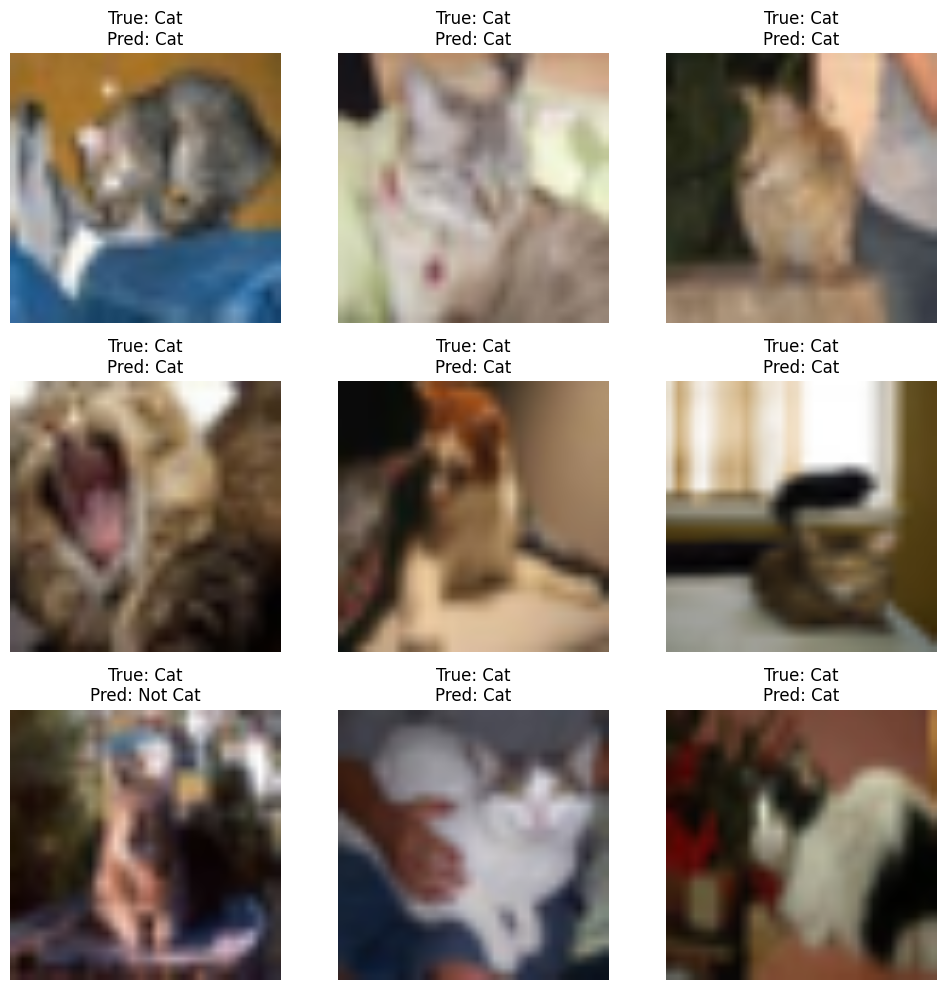

In [14]:
# Plot some example predictions
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i])
    ax.set_title(f"True: {'Cat' if test_labels[i] == 1 else 'Not Cat'}\n"
                 f"Pred: {'Cat' if predicted_labels[i] == 1 else 'Not Cat'}")
    ax.axis('off')
plt.tight_layout()
plt.show()

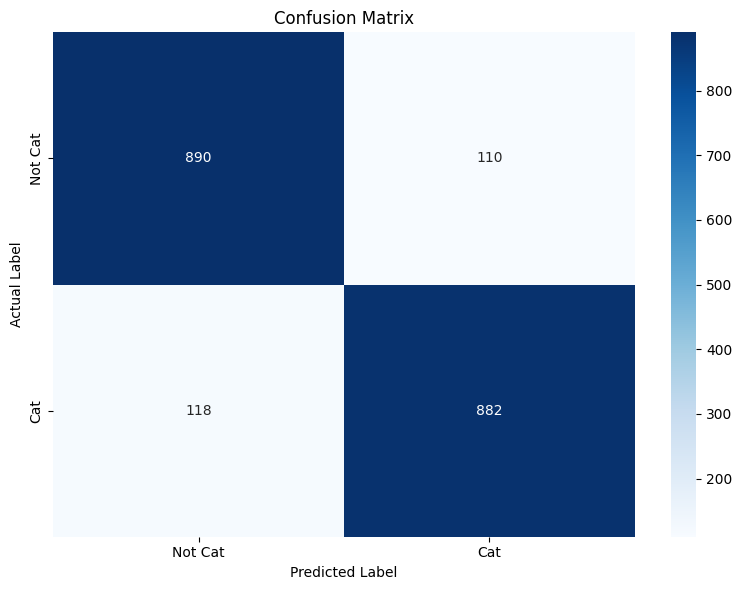

              precision    recall  f1-score   support

     Not Cat       0.88      0.89      0.89      1000
         Cat       0.89      0.88      0.89      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



In [15]:

# Computing the confusion matrix
cm = confusion_matrix(test_labels, predicted_labels)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks([0.5, 1.5], ['Not Cat', 'Cat'])
plt.yticks([0.5, 1.5], ['Not Cat', 'Cat'])
plt.tight_layout()
plt.show()

# Printing classification report
from sklearn.metrics import classification_report
print(classification_report(test_labels, predicted_labels, target_names=['Not Cat', 'Cat']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


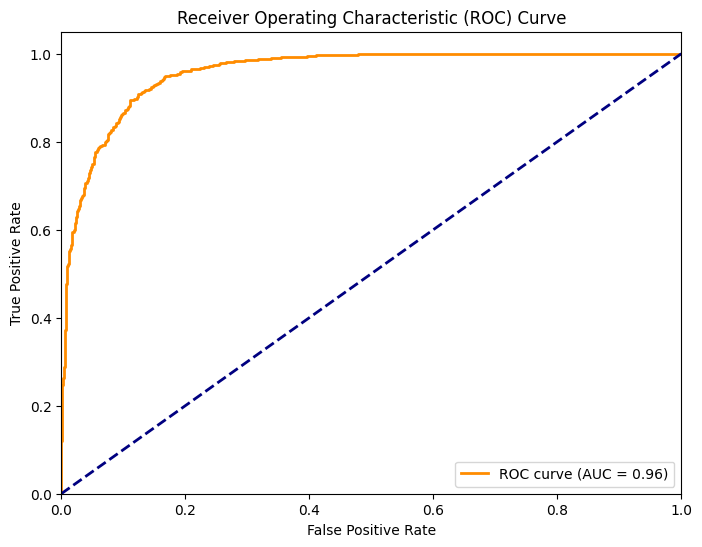

AUC: 0.96


In [16]:
#ROC curve plotting

#Get the predicted probabilities for the positive class (cat)
y_pred_proba = model.predict(test_images).flatten()

# Compute ROC curve and area under curve
fpr, tpr, thresholds = roc_curve(test_labels, y_pred_proba)
roc_auc = auc(fpr, tpr)

#Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

#Print AUC score
print(f'AUC: {roc_auc:.2f}')